## Imports & Setup

In [1]:
import torch
import matplotlib.pyplot as plt
import os
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Import from your custom modules
import config
from utils.dataloader import get_dataloaders
from utils.engine import train_model
from models.densenet121 import DenseNet121

print(f"Using Device: {config.DEVICE}")
print(f"Batch Size: {config.BATCH_SIZE} | Image Size: {config.IMG_SIZE}")

Using Device: cuda
Batch Size: 32 | Image Size: 224


## Load the Dataset

In [2]:
# Fetch dataloaders and class names
train_loader, val_loader, test_loader, class_names = get_dataloaders()

# Verify a batch shape
images, labels = next(iter(train_loader))
print(f"\nBatch image shape: {images.shape}")
print(f"Batch label shape: {labels.shape}")

Image size   : 224×224
Train images : 1000
Val images   : 36
Test images  : 38
Classes      : ['Angry', 'Other', 'Sad', 'happy']

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])


## Initialize DenseNet121

In [3]:
# Initialize the model and push to GPU
model = DenseNet121(num_classes=config.NUM_CLASSES).to(config.DEVICE)

# Optional: Count parameters to see the size of your from-scratch model
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"DenseNet121 Total Trainable Parameters: {total_params:,}")

DenseNet121 Total Trainable Parameters: 6,957,956


## Execute Training Loop

In [4]:
# Run the training engine
trained_model, best_accuracy, all_preds, all_labels = train_model(
    model=model,
    model_name="DenseNet121_FromScratch",
    train_loader=train_loader,
    val_loader=val_loader,
    class_names=class_names,
    epochs=config.EPOCHS,
    patience=7 
)

print(f"\nTraining Complete! Best Validation Accuracy: {best_accuracy:.4f}")


  Training : DenseNet121_FromScratch  |  device: cuda
Epoch [ 1/30]  Train Loss: 1.4576  Train Acc: 0.2850  |  Val Loss: 1.6669  Val Acc: 0.2500
  Model saved with Val Acc: 0.2500
Epoch [ 2/30]  Train Loss: 1.4488  Train Acc: 0.2680  |  Val Loss: 1.4481  Val Acc: 0.3611
  Model saved with Val Acc: 0.3611
Epoch [ 3/30]  Train Loss: 1.4058  Train Acc: 0.3200  |  Val Loss: 1.4982  Val Acc: 0.2778
  EarlyStopping: no improvement for 1/7 epochs
Epoch [ 4/30]  Train Loss: 1.3957  Train Acc: 0.3060  |  Val Loss: 2.4915  Val Acc: 0.1944
  EarlyStopping: no improvement for 2/7 epochs
Epoch [ 5/30]  Train Loss: 1.4057  Train Acc: 0.2870  |  Val Loss: 1.3487  Val Acc: 0.3611
Epoch [ 6/30]  Train Loss: 1.4173  Train Acc: 0.2810  |  Val Loss: 1.3069  Val Acc: 0.3333
Epoch [ 7/30]  Train Loss: 1.3784  Train Acc: 0.3310  |  Val Loss: 1.4029  Val Acc: 0.2500
  EarlyStopping: no improvement for 1/7 epochs
Epoch [ 8/30]  Train Loss: 1.4053  Train Acc: 0.3010  |  Val Loss: 1.3767  Val Acc: 0.2500
  Earl

## Visualize Training History

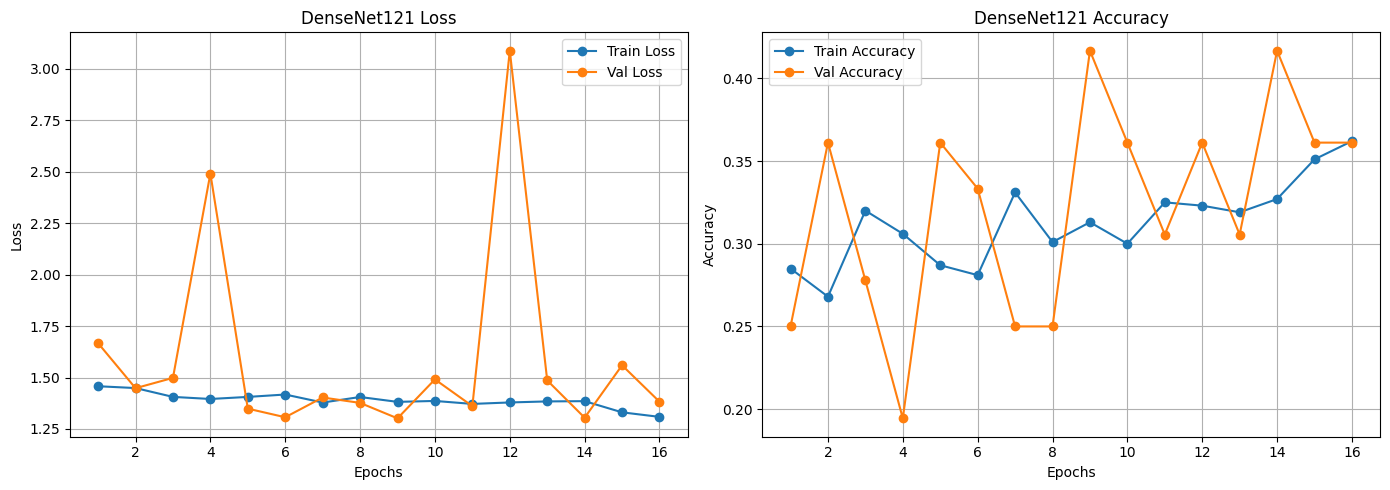

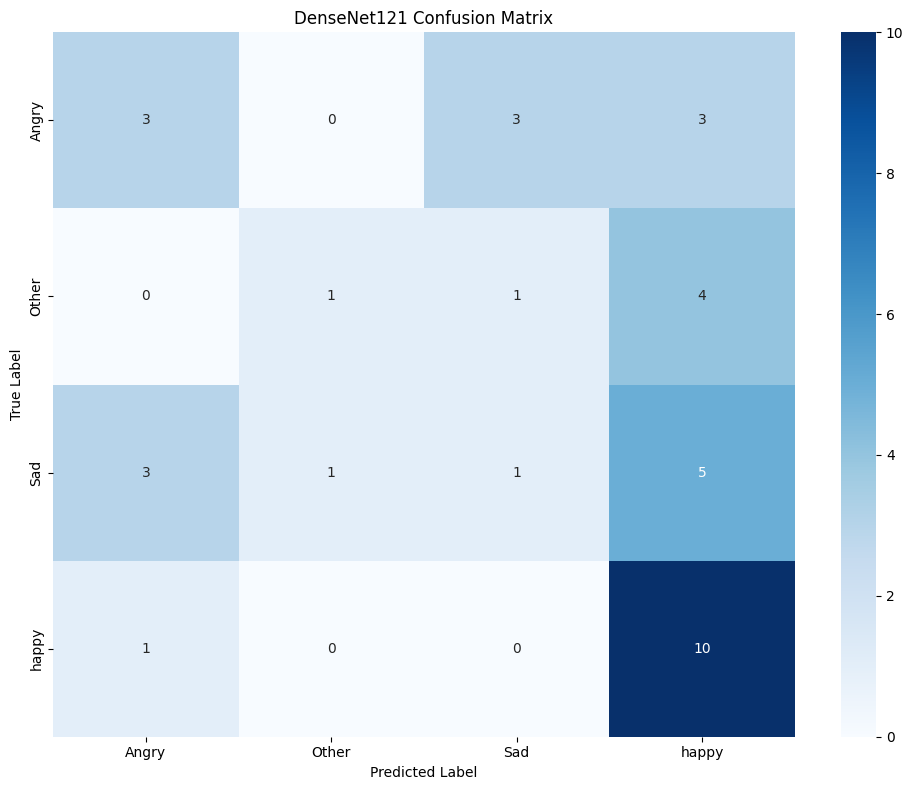

In [5]:
# Load the saved history
history_path = os.path.join(config.CHECKPOINT_DIR, "DenseNet121_FromScratch_history.pt")

if os.path.exists(history_path):
    history = torch.load(history_path)
    
    epochs_range = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
    plt.plot(epochs_range, history['val_loss'], label='Val Loss', marker='o')
    plt.title('DenseNet121 Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_acc'], label='Train Accuracy', marker='o')
    plt.plot(epochs_range, history['val_acc'], label='Val Accuracy', marker='o')
    plt.title('DenseNet121 Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)

    plt.title('DenseNet121 Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
else:
    print("History file not found.")